In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
from scipy import stats

In [2]:
#Load Dataset Using Pandas

df = pd.read_csv("/content/Retail_Dataset_Cleaned 11.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
#Task 1: Validating Business Assumptions Using Hypothesis Testing
# Display First Five Records

df.head()

,Store_ID,Store_Name,Brand_Name,Store_Type,City,City_Tier,Product_Name,Category,Sub_Category,Product_Stage,...,Brand_Loyalty,Brand_Awareness,Price_Competitiveness,Weather_Impact,Delivery_Time,Shipping_Cost,Month,Year,Quarter,Season
0,Bx_Pune_034,Brandx_India Superstore Pune,Brandx_India,Flagship,Pune,Tier1,Green Tea 100G,Groceries,Tea,Declining,...,70.8,75.7,Standard,Low,6,57,1,2022,Q1,Spring
1,Bx_Mumbai_023,Brandx_India Superstore Mumbai,Brandx_India,Street Store,Mumbai,Metro,White Sugar 1Kg,Groceries,Sugar,Declining,...,80.5,81.5,Competitive,Low,4,99,1,2022,Q1,Spring
2,Bx_Pune_073,Brandx_India Trends Pune,Brandx_India,Flagship,Pune,Tier1,Levi'S T-Shirt,Clothes,T-Shirts,Declining,...,68.5,76.7,Standard,Medium,4,101,1,2022,Q1,Spring
3,Bx_Chennai_061,Brandx_India Trends Chennai,Brandx_India,Mall Store,Chennai,Metro,Adidas Hoodie,Clothes,Jackets,New Launch,...,92.4,88.0,Competitive,Medium,5,79,1,2022,Q1,Spring
4,Bx_Chennai_033,Brandx_India Connect Chennai,Brandx_India,Mall Store,Chennai,Metro,Playstation 5,Gadgets,Gaming Consoles,Declining,...,82.9,89.5,Competitive,Low,2,110,1,2022,Q1,Spring


In [ ]:
#Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5146 entries, 0 to 5145
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_ID               5146 non-null   object 
 1   Store_Name             5146 non-null   object 
 2   Brand_Name             5146 non-null   object 
 3   Store_Type             5146 non-null   object 
 4   City                   5146 non-null   object 
 5   City_Tier              5146 non-null   object 
 6   Product_Name           5146 non-null   object 
 7   Category               5146 non-null   object 
 8   Sub_Category           5146 non-null   object 
 9   Product_Stage          5146 non-null   object 
 10  Quantity_Available     5146 non-null   int64  
 11  Units_Sold             5146 non-null   int64  
 12  Unit_Price             5146 non-null   int64  
 13  Cost_Price             5146 non-null   int64  
 14  Revenue                5146 non-null   int64  
 15  Prof

In [ ]:
#Display Column Names

df.columns

Index(['Store_ID', 'Store_Name', 'Brand_Name', 'Store_Type', 'City',
       'City_Tier', 'Product_Name', 'Category', 'Sub_Category',
       'Product_Stage', 'Quantity_Available', 'Units_Sold', 'Unit_Price',
       'Cost_Price', 'Revenue', 'Profit_Margin', 'Average_Order_Value',
       'Inventory_Turnover', 'Days_of_Stock', 'Customer_Segment',
       'Sales_Channel', 'Payment_Method', 'Supplier', 'Supplier_Rating',
       'Promotion_Type', 'Promotion_Impact', 'Max_Discount_Offered',
       'Return_Rate', 'Return_Reason', 'Customer_Satisfaction',
       'Online_Rating', 'Review_Count', 'Sales_Rep_Experience',
       'Sales_Rep_Rating', 'Market_Share', 'Competition_Level',
       'Competitor_Count', 'Brand_Loyalty', 'Brand_Awareness',
       'Price_Competitiveness', 'Weather_Impact', 'Delivery_Time',
       'Shipping_Cost', 'Month', 'Year', 'Quarter', 'Season'],
      dtype='object')

In [ ]:
#Compare Customer Satisfaction Between Two Store Types
# a) Extract Sample Data

flagship = df[df["Store_Type"]=="Flagship"]["Customer_Satisfaction"]

mall = df[df["Store_Type"]=="Mall Store"]["Customer_Satisfaction"]

In [ ]:
# b) Perform Independent T-Test

t_stat, p_value = stats.ttest_ind(
    flagship,
    mall,
    nan_policy="omit"
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 0.5195690551232559
P Value: 0.6034184941873542


In [ ]:
# Interpret the Result

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [ ]:
# Task 2: Measuring Statistical Evidence Using P-Values
# Check Whether Average Order Value Differs Across Customer Segments

df.groupby("Customer_Segment")[
    "Average_Order_Value"
].mean()

,Average_Order_Value
Customer_Segment,
Budget,44367.475513
Luxury,48157.249231
Mid-Range,45809.167442
Premium,41913.748062


In [ ]:
# Compare Average Order Values of Premium and Budget Customers

premium = df[
    df["Customer_Segment"]=="Premium"
]["Average_Order_Value"]

budget = df[
    df["Customer_Segment"]=="Budget"
]["Average_Order_Value"]

In [ ]:
# Calculate Test Statistic and P-Value

t_stat, p_value = stats.ttest_ind(
    premium,
    budget,
    nan_policy="omit"
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: -0.9499873137747873
P Value: 0.3422085832949139


In [ ]:
#Business Decision

if p_value < 0.05:
    print("Customer segments have significantly different order values.")
else:
    print("No significant difference found.")

No significant difference found.


In [3]:
# Task 3: Understanding Sampling Behavior Using the Central Limit Theorem
# Import Visualization Library
import matplotlib.pyplot as plt


In [4]:
# Generate Sample Means from Revenue

sample_means = []

for i in range(100):
    sample = df["Revenue"].sample(
        n=30,
        replace=True
    )

    sample_means.append(sample.mean())

In [8]:
# Convert into DataFrame

sample_df = pd.DataFrame(
    {"Sample_Mean": sample_means}
)

sample_df.head()

,Sample_Mean
0,2.125884e+06
1,1.566847e+06
2,1.963603e+06
3,1.392257e+06
4,7.943313e+05


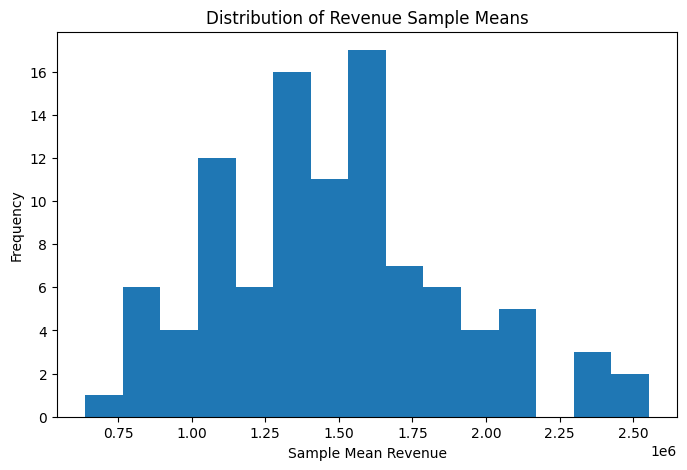

In [10]:
# Plot Distribution of Sample Means

plt.figure(figsize=(8,5))

plt.hist(
    sample_df["Sample_Mean"],
    bins=15
)

plt.title(
    "Distribution of Revenue Sample Means"
)
plt.xlabel("Sample Mean Revenue")
plt.ylabel("Frequency")

plt.show()

In [11]:
# Calculate Mean and Standard Deviation

print(
    "Mean of Sample Means:",
    sample_df["Sample_Mean"].mean()
)
print(
    "Standard Deviation:",
    sample_df["Sample_Mean"].std()
)

Mean of Sample Means: 1483277.134666667
Standard Deviation: 404063.85827248724
